# Topic 1: ZüriWieNeu Project: Spatial and Temporal Analysis of Citizen Reports in Zurich (2013-2026)

## Introduction
This project investigates citizen reports from the "ZüriWieNeu" platform to identify spatial and temporal patterns in Zurich neighborhoods.

The main research question is: *What spatial and temporal patterns characterize citizen reports in Zurich between 2013 and 2026?*

Sub-Questions:
1. Which neighborhoods reported the highest number of issues from 2013 to 2026?
2. Which issue categories were most frequent in each neighborhood during this period?
3. How has reporting activitiy evolved over the years?
4. Are there seasonal trends in reporting activity between 2013 and 2026?

In [279]:
# Import required libraries
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt

## Loading and Preparing the ZüriWieNeu Data

The ZüriWieNeu dataset was loaded as a CSV file using pandas. 
Coordinates were converted into geometries with GeoPandas to enable spatial operations. 
Datetime columns were converted from string format to datetime format.
Seperate columns for the year and month were created for temporal analysis.

In [280]:
# Load ZüriWieNeu citizen report data
data_zwn = pd.read_csv("../data/raw/stzh.zwn_meldungen_p.csv")

#Renaming the coumns
data_zwn = data_zwn.rename(columns={
    "e":"x",
    "n": "y"
})

# Convert to GeoDataFrame
zwn_gdf = gpd.GeoDataFrame (
    data_zwn, 
    geometry=gpd.points_from_xy(data_zwn["x"], data_zwn["y"]),
    crs="EPSG:2056"
)

# Convert datetime columns
zwn_gdf["requested_datetime"] = pd.to_datetime(zwn_gdf["requested_datetime"])
zwn_gdf["agency_sent_datetime"] = pd.to_datetime(zwn_gdf["agency_sent_datetime"])
zwn_gdf["updated_datetime"] = pd.to_datetime(zwn_gdf["updated_datetime"])

# Extract requested year and month for temporal analysis
zwn_gdf["year_requested"] = zwn_gdf["requested_datetime"].dt.year
zwn_gdf["month_requested"] = zwn_gdf["requested_datetime"].dt.month

# Match numbers to month names
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

# New column with month names
zwn_gdf["month_name_requested"] = zwn_gdf["month_requested"].map(month_names)
month_order = [
    "January", "February", "March","April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]
zwn_gdf["month_name_requested"] = pd.Categorical(
    zwn_gdf["month_name_requested"],
    categories=month_order,
    ordered=True
)


# Removing unnexessary columns
zwn_gdf = zwn_gdf.drop(columns=[
    "agency_sent_datetime", "updated_datetime", "status", "detail", "media_url", 
    "interface_used", "service_notice", "description", "url", "title", "userid",
    "x", "y"
])


## Loading and Preparing the Quartiere Data

The Quartiere dataset, representing the neighborhoods of Zurich, consists of two layers: geometries and attributes such as neighborhood names. Both layers were merged.
The active geometry column was kept and the dataset was reprojected to match the CRS of the citizen report data.
Neighborhood areas were calculated for density based analyses. 

In [281]:
# Load Quartiere data
quartiere_geom = gpd.read_file("../data/raw/stzh.adm_statistische_quartiere_map.json")
quartiere_attr = gpd.read_file("../data/raw/stzh.adm_statistische_quartiere_b_p.json")

# Merge geometry and attributes
quartiere = quartiere_geom.merge(quartiere_attr, on="objectid")

# Keep active geometry and drop unnecessary columns
quartiere = quartiere.rename(columns={"geometry_x": "geometry"})
quartiere = quartiere.set_geometry("geometry")
quartiere = quartiere.drop(columns=["geometry_y", "objid", "ori", "hali", "vali"])

# Reproject to match ZüriWieNeu CRS
quartiere = quartiere.to_crs(epsg=2056)

# Calculate area
quartiere["area_m2"] = quartiere.geometry.area
quartiere["area_km2"] = quartiere["area_m2"] / 1000000


## Joining Citizen Reports with Neighborhoods

A point-in-polygon spatial join was performed to assign each citizen report to the corresponding neighborhood.

In [282]:
# Spatial Join: assign each report to a neighborhood
zwn_quartiere_joined = gpd.sjoin(zwn_gdf, quartiere, predicate="within")

# Removing unnecessary columns
zwn_quartiere_joined = zwn_quartiere_joined.drop(columns=[
    "index_right", "objectid_left", "objectid_right"
])


## Research Question 1: Neighborhoods with the Highest Number of Reports from 2013 - 2026

Reports were accumulated by neighborhood. 
The top 10 neighborhoods with the most reports over the years are identified. 

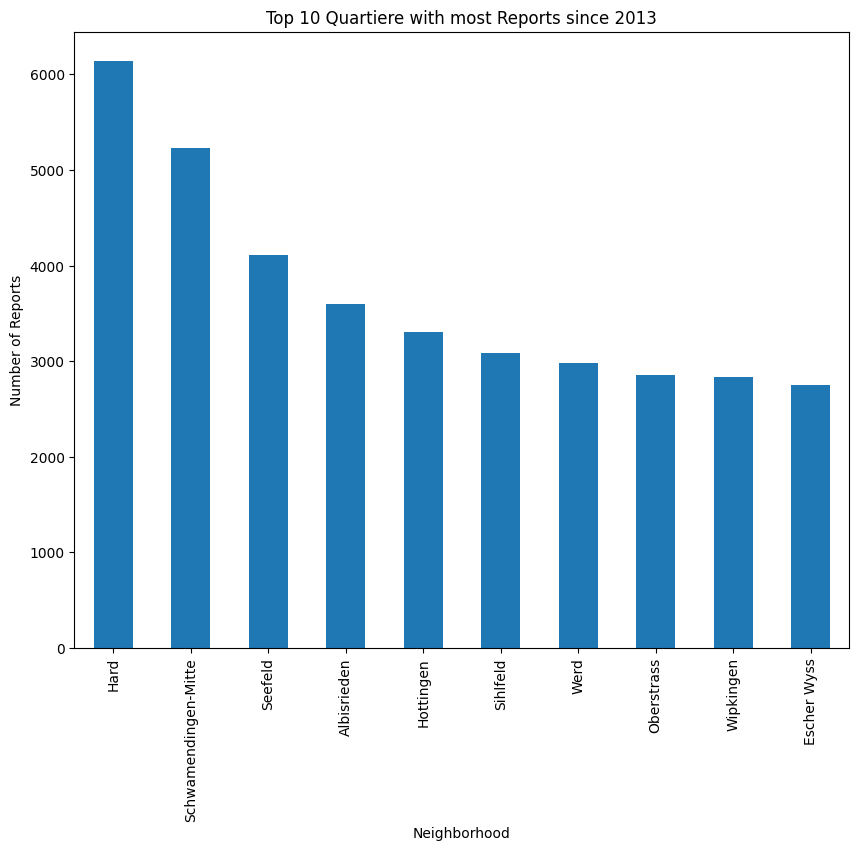

In [283]:
# Count reports per neighborhood
report_counts = (zwn_quartiere_joined.groupby("name").size().reset_index(name="report_count"))

# Top 10 neighborhoods
top10_quartier_reports = report_counts.sort_values(by="report_count", ascending=False).head(10)

# Plotting bar chart
ax = top10_quartier_reports.plot(
    kind="bar", 
    x = "name", 
    y = "report_count", 
    figsize = (10,8), 
    title = "Top 10 Quartiere with most Reports since 2013", 
    legend=False
)

ax.set_xlabel("Neighborhood")
ax.set_ylabel("Number of Reports")


plt.savefig("../outputs/top10_neighborhoods_bar.png", dpi=300, bbox_inches="tight")

plt.show()

### Report density per km2

For spatial visualization report counts are normalized by neighborhood area.

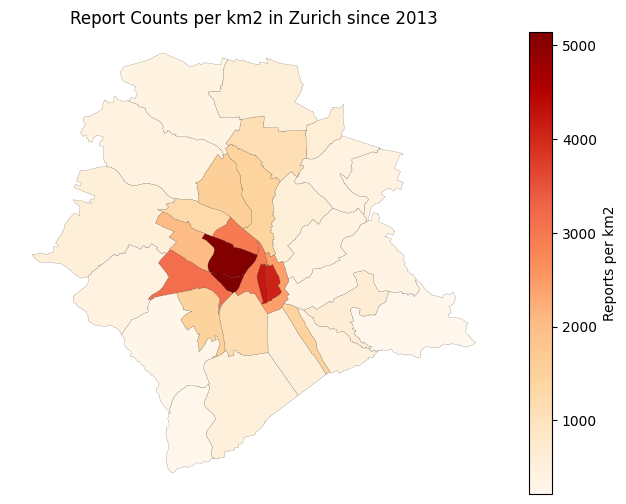

In [284]:
quartiere_reports = quartiere.merge (report_counts, on="name", how="left")
quartiere_reports["reports_per_km2"] = quartiere_reports["report_count"] /quartiere_reports["area_km2"]

# Creating Legend Options
legend_options = {
     "label": "Reports per km2",
     "orientation": "vertical",
     "pad": 0.05
}
# Plotting choropleth map
ax = quartiere_reports.plot(
    column="reports_per_km2",
    cmap="OrRd",
    figsize =(8,6), 
    legend=True, 
    edgecolor="black",
    linewidth=0.1,
    legend_kwds=legend_options
)

ax.set_title("Report Counts per km2 in Zurich since 2013")
ax.axis("off")


plt.savefig("../outputs/report_counts_Zurich_choropleth.png", dpi=300, bbox_inches="tight")


plt.show()

## Research Question 2: Which issue categories were most frequent and where

The top 3 service codes are selected for separate choropleth maps. 
Report counts are normalized by area for comparability. 

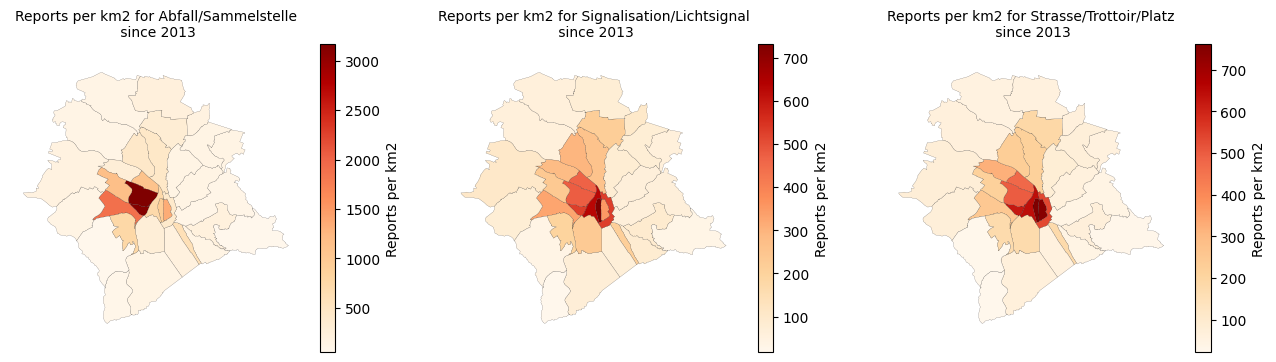

In [285]:
# Top 3 frequently reported service codes
top3_codes = zwn_quartiere_joined["service_code"].value_counts().head(3).index

# Preparing subplot with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(16,4))

# Loop through top 3 service codes to create individual choropleth maps
for i, code in enumerate(top3_codes):
    code_data = zwn_quartiere_joined[zwn_quartiere_joined["service_code"] == code]
   
    service_counts = code_data.groupby("name").size().reset_index(name="service_counts")
    
    # Merging the counts with the Quartiere GeoDataFrame
    quartiere_code = quartiere.merge(service_counts, on="name", how="left")

    #Fill missing values with 0
    quartiere_code["service_counts"] = quartiere_code["service_counts"].fillna(0)
    
    # Calculating report density per km2 for service code
    quartiere_code ["service_per_km2"] = quartiere_code["service_counts"] / quartiere_code["area_km2"]
    
    # Creating Legend Options
    legend_options = {
        "label": "Reports per km2",
        "orientation": "vertical",
        "pad": 0.05
    }
    #Plotting choropleth maps
    quartiere_code.plot(
        column="service_per_km2", 
        cmap="OrRd", 
        ax=axes[i], 
        edgecolor="black",
        linewidth=0.1, 
        legend=True,
        legend_kwds=legend_options
    )

    axes[i].set_title(f"Reports per km2 for {code}\n since 2013", fontsize=10)
    axes[i].axis("off")


plt.savefig("../outputs/report_counts_neighborhoods_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()


## Research Question 3: Temporal Evolution of Reports including COVID-19 Impact

Reports are grouped by year to analyze temporal trends.
A monthly breakdown is included for 2020 to show the effecr of the COVID-19 pandemic. 

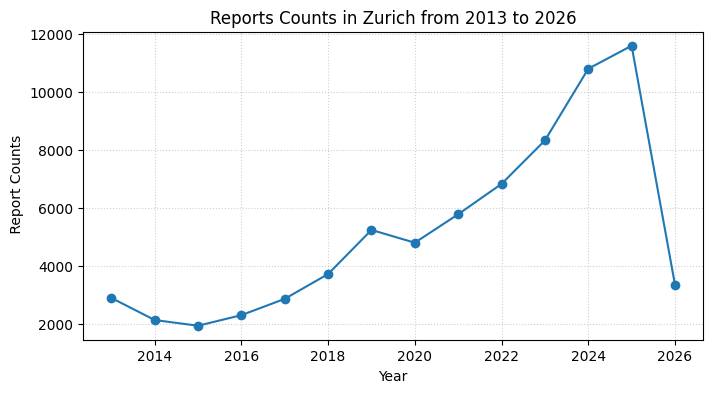

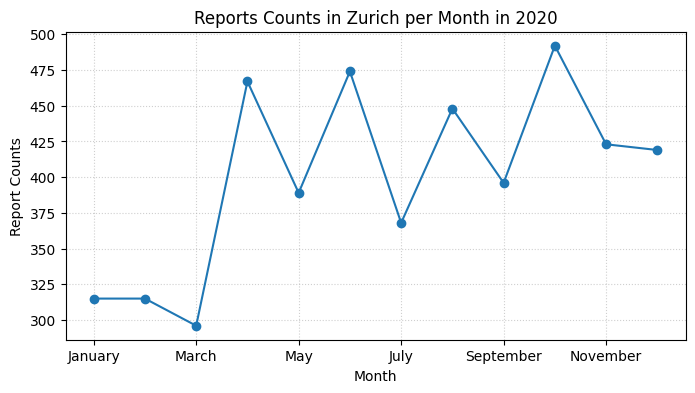

In [286]:
# Reports per year
reports_over_year = (zwn_quartiere_joined.groupby("year_requested").size())

# Plotting line chart over all years
ax = reports_over_year.plot(
    kind="line", 
    figsize=(8,4), 
    title= "Reports Counts in Zurich from 2013 to 2026", 
    x="year_requested", 
    y="report_counts", 
    marker="o"
)

ax.set_ylabel(" Report Counts")
ax.set_xlabel("Year")
ax.grid(True, linestyle=":", alpha=0.6)

plt.savefig("../outputs/report_counts_yearly_line.png", dpi=300, bbox_inches="tight")

plt.show()

# Reports in 2020 
reports_2020 = zwn_quartiere_joined[zwn_quartiere_joined["year_requested"] ==2020]
monthly_2020 = (reports_2020.groupby("month_name_requested").size().reset_index(name="report_count_2020"))

# Plotting line chart for 2020
ax = monthly_2020.plot(
    kind="line",
    figsize=(8,4),
    title="Reports Counts in Zurich per Month in 2020", 
    x="month_name_requested", 
    y="report_count_2020", 
    marker="o", 
    legend=False
)

ax.set_xlabel("Month")
ax.set_ylabel("Report Counts")
ax.grid(True, linestyle=":", alpha=0.6)

plt.savefig("../outputs/report_counts_monthly_2020.png", dpi=300, bbox_inches="tight")

plt.show()

## Research Question 4: Seasonal Reporting Trends

Monthly reports are accumulated across al years to examine seasonal patterns.

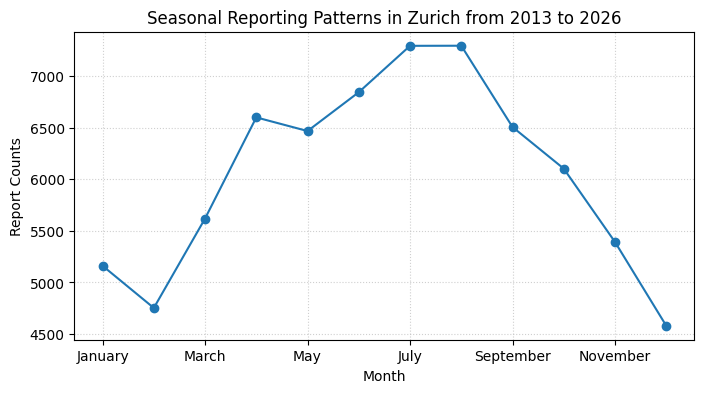

In [287]:
# Seasonal counts
seasonal_counts = (zwn_quartiere_joined.groupby("month_name_requested").size().reset_index(name="seasonal_count"))

# Plotting line chart
ax = seasonal_counts.plot(
    kind="line", 
    figsize= (8,4), 
    title="Seasonal Reporting Patterns in Zurich from 2013 to 2026", 
    x="month_name_requested", 
    y="seasonal_count", 
    marker="o", 
    legend=False
)
ax.set_xlabel("Month")
ax.set_ylabel("Report Counts")
ax.grid(True, linestyle=":", alpha=0.6)

plt.savefig("../outputs/report_counts_Zurich_monthly_line.png", dpi=300, bbox_inches="tight")

plt.show()